In [1]:
!pip install pandas

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Amazon Sales Data Analysis

##  Project Overview
# This project focuses on performing Exploratory Data Analysis (EDA) on an e commerce dataset similar to Amazon. The goal is to uncover insights related to sales performance, customer purchasing behavior, product category trends, and profitability patterns.


In [3]:
df = pd.read_csv(r"C:\Users\HP\Downloads\amazon_sales_dataset.csv")

In [ ]:
## Data Loading and Understanding

# The dataset was loaded using pandas and explored to understand its structure, column names, and data types.

## Key steps performed:
# Displayed the first and last few rows
# Checked dataset shape (rows and columns)
# Reviewed column names
# Inspected data types using 

# This step helps us identify necessary cleaning and transformations.

In [13]:
##show first few rows
df.head(5)

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,total_cost,profit
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,515.00,51.48
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,1513.00,302.60
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,991.60,198.32
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,1487.80,223.16
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,806.72,0.00


In [14]:
##show few last rows
df.tail(5)

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,total_cost,profit
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95,134.95,0.00
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05,1471.15,147.10
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92,1408.44,422.52
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16,307.54,15.38
49999,50000,2023-06-29,2944,Home & Kitchen,253.44,30,1,Europe,Debit Card,2.1,464,177.41,177.41,253.44,76.03


In [15]:
## Check shapes and column names
df.columns


Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue', 'total_cost', 'profit'],
      dtype='object')

In [16]:
## Check shapes
df.shape

(50000, 15)

In [20]:
##Understand data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          50000 non-null  int64         
 1   order_date        50000 non-null  datetime64[ns]
 2   product_id        50000 non-null  int64         
 3   product_category  50000 non-null  object        
 4   price             50000 non-null  float64       
 5   discount_percent  50000 non-null  int64         
 6   quantity_sold     50000 non-null  int64         
 7   customer_region   50000 non-null  object        
 8   payment_method    50000 non-null  object        
 9   rating            50000 non-null  float64       
 10  review_count      50000 non-null  int64         
 11  discounted_price  50000 non-null  float64       
 12  total_revenue     50000 non-null  float64       
 13  total_cost        50000 non-null  float64       
 14  profit            5000

In [ ]:
## Data Cleaning
# Steps performed:
# Checked for missing values 
# Verified duplicate records 
# Converted order_date to datetime format
# Ensured numeric columns were properly formatted


In [18]:
##Checking missing values
df.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
total_cost          0
profit              0
dtype: int64

In [23]:
##Check for duplicates
df.duplicated().sum()

np.int64(0)

In [19]:
##Convert date columns to proper datetime column
df['order_date']=pd.to_datetime(df['order_date'])


In [21]:
##Checking if the conversion worked
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          50000 non-null  int64         
 1   order_date        50000 non-null  datetime64[ns]
 2   product_id        50000 non-null  int64         
 3   product_category  50000 non-null  object        
 4   price             50000 non-null  float64       
 5   discount_percent  50000 non-null  int64         
 6   quantity_sold     50000 non-null  int64         
 7   customer_region   50000 non-null  object        
 8   payment_method    50000 non-null  object        
 9   rating            50000 non-null  float64       
 10  review_count      50000 non-null  int64         
 11  discounted_price  50000 non-null  float64       
 12  total_revenue     50000 non-null  float64       
 13  total_cost        50000 non-null  float64       
 14  profit            5000

In [163]:
##Ensure numeric columns
df['total_revenue'] = pd.to_numeric(df['total_revenue'])

In [164]:
df['quantity_sold'] = pd.to_numeric(df['quantity_sold'])

In [165]:
df['price'] = pd.to_numeric(df['price'])

In [166]:
df['discounted_price'] = pd.to_numeric(df['discounted_price'])

In [167]:
df['discount_percent'] = pd.to_numeric(df['discount_percent'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
 13  total_cost        50000 non-null  float64
 14  profit            50000 non-null  float64
dtypes: float64(6), int64(5), object(4)
memory usage: 5.7+ MB


In [ ]:
## Profit and Cost Calculation
# The dataset did not include cost or profit information. Therefore, these values were calculatedto enable profitability analysis.

### Calculations:
# For total cost ; total_cost = quantity_sold * price
# For total profit; profit = total_cost - total_revenue
# This calculation  allows us to be able to answer qustions that needed profit and total cost. 

In [5]:
##calculating total cost
df['total_cost'] = df['quantity_sold']*df['price']

In [6]:
##Calculating total profit
df['profit'] = df['total_cost'] - df['total_revenue']

In [ ]:
## Overall Sales Performance
# This section evaluates the total revenue, total quantity sold, and estimated profit.
# These provide a  view of the company’s performance and scale of operations.

In [11]:
##EDA QUESTIONS
## What is the total sales, total profit, and total quantity sold?
total_revenue = df['total_revenue'].sum()
print(total_revenue)
print(f"Total Revenue: {total_revenue:,.2f}")

32866573.740000002
Total Revenue: 32,866,573.74


In [29]:
##total profit
total_profit = df['profit'].sum()
print(total_profit)
print(f"Total Profit: {total_profit:,.2f}")

5046530.8
Total Profit: 5,046,530.80


In [65]:
##Total Quantity Sold
total_quantity_sold = df['quantity_sold'].sum()
print(total_quantity_sold)
print(f"Total quantity sold: {total_quantity_sold:,.2f}")

149970
Total quantity sold: 149,970.00


In [ ]:
## Sales Trend Over Time
#This analysis examines how sales have changed over time on a yearly basis.
#Understanding trends over time helps identify growth patterns, stability, in the business.

In [112]:
##  How do sales change over time (monthly or yearly trend)?
df['Month'] = pd.to_datetime(df['order_date']).dt.to_period('M')


In [44]:
##Yearly sales trend 
df['year'] = df['order_date'].dt.year

year
2022    16389404.56
2023    16477169.18
Name: total_revenue, dtype: float64


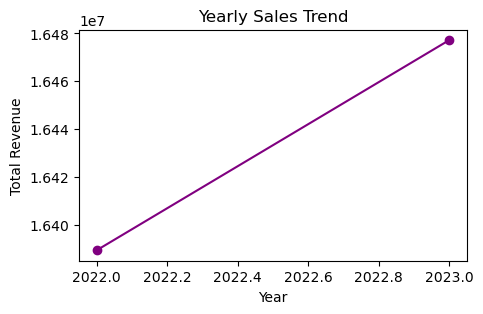

In [45]:
yearly_sales = df.groupby('year')['total_revenue'].sum()
print(yearly_sales)
yearly_sales.plot(kind='line', color='purple', figsize =(5,3),marker='o')
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Revenue')
plt.show()

In [ ]:
## Insight; Sales remained stable across the years, showing steady business performance without major fluctuations.

In [ ]:
## Category Performance
# This section analyzes how different product categories contribute to total revenue and profit.
# It helps identify which categories are contributing highly to business success.

In [40]:
## Which product categories generate the highest sales and profit?
category_sales = df.groupby('product_category')['total_revenue'].sum()
print(category_sales)

product_category
Beauty            5550624.97
Books             5484863.03
Electronics       5470594.03
Fashion           5480123.34
Home & Kitchen    5473132.55
Sports            5407235.82
Name: total_revenue, dtype: float64


In [41]:
category_profit = df.groupby('product_category')['profit'].sum()
print(category_profit)

product_category
Beauty            854361.49
Books             850345.81
Electronics       832574.49
Fashion           839718.81
Home & Kitchen    824399.96
Sports            845130.24
Name: profit, dtype: float64


In [ ]:
## Insight; Beauty contributes highly to total revenue and profit, however the remaining products are not far off. Which showcase a balance. 

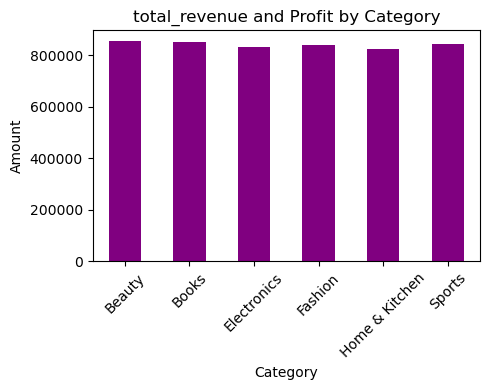

In [42]:
category_profit.plot(kind='bar', color='purple' ,figsize=(5,3))
plt.title('total_revenue and Profit by Category')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.show()

In [34]:
## What are the top 5 sub-categories by sales or profit?
top_sub = df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False).head(5)
print(top_sub)

product_category
Beauty            5550624.97
Books             5484863.03
Fashion           5480123.34
Home & Kitchen    5473132.55
Electronics       5470594.03
Name: total_revenue, dtype: float64


In [36]:
top_sub = df.groupby('product_category')['profit'].sum().sort_values(ascending=False).head(5)
print(top_sub)

product_category
Beauty         854361.49
Books          850345.81
Sports         845130.24
Fashion        839718.81
Electronics    832574.49
Name: profit, dtype: float64


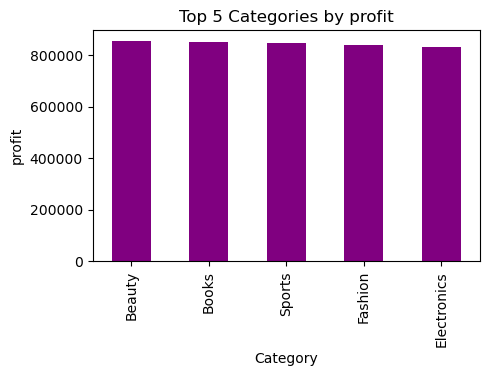

In [38]:
top_sub.plot(kind='bar' , color='purple', figsize=(5,3))
plt.title('Top 5 Categories by profit')
plt.xlabel('Category')
plt.ylabel('profit')
plt.show()

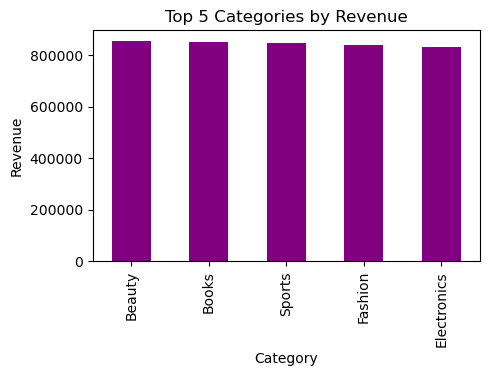

In [37]:
top_sub.plot(kind='bar', color='purple' , figsize=(5,3))
plt.title('Top 5 Categories by Revenue')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.show()

In [ ]:
## Regional Performance
# This section evaluates sales and profit across different customer regions. It helps identify strong and weak region.

In [81]:
## Which region performs best in terms of sales and profit?
region = df.groupby('customer_region')['total_revenue'].sum()
print(region)

customer_region
Asia             8175199.83
Europe           8112311.57
Middle East      8301844.50
North America    8277217.84
Name: total_revenue, dtype: float64


In [30]:
region = df.groupby('customer_region')['profit'].sum()
print(region)

customer_region
Asia             1274937.84
Europe           1247611.85
Middle East      1267824.46
North America    1256156.65
Name: profit, dtype: float64


In [ ]:
## Insight
# Asia generates both highest revenue and profit than others,tho the margin with other region is not a lot. 

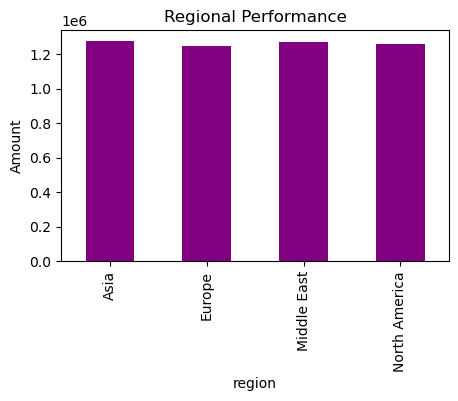

In [31]:
region.plot(kind='bar', color= 'purple',figsize=(5,3))
plt.title('Regional Performance')
plt.xlabel('region')
plt.ylabel('Amount')
plt.show()

In [ ]:
## Profitability Analysis
# This analysis examines profit margins across product categories to identify areas of high sales and low profit.

# Profit margin is calculated as: Profit ÷ Total revenue

In [12]:
## Are there categories or sub-categories with high sales but low profit?
profit_margin = df.groupby('product_category')[['total_revenue','profit']].sum()
profit_margin['margin'] = profit_margin['profit'] / profit_margin['total_revenue']
print(profit_margin)



                  total_revenue     profit    margin
product_category                                    
Beauty               5550624.97  854361.49  0.153922
Books                5484863.03  850345.81  0.155035
Electronics          5470594.03  832574.49  0.152191
Fashion              5480123.34  839718.81  0.153230
Home & Kitchen       5473132.55  824399.96  0.150627
Sports               5407235.82  845130.24  0.156296


In [ ]:
##Insight
# Profit margins across all product categories are relatively similar.There are no category with high sales and low profit.

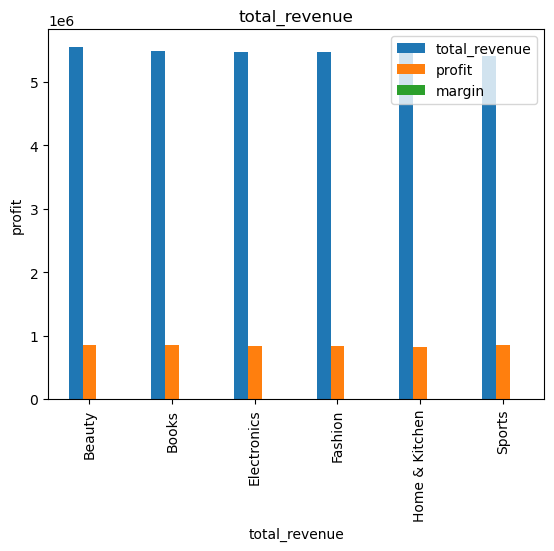

In [23]:
profit_margin.plot(kind='bar')
plt.title('Profit Margin by Category' and 'total_revenue')
plt.xlabel('total_revenue')
plt.ylabel('profit')
plt.show()

In [ ]:
## Customer Purchasing Behavior
# This section analyzes the distribution of quantity sold per transaction. It helps understand how customers purchase products.

In [58]:
## What is the distribution of order quantities? Do customers tend to buy in small or large quantities?
df['quantity_sold'].value_counts().sort_index()


quantity_sold
1    10060
2     9914
3    10026
4     9996
5    10004
Name: count, dtype: int64

In [ ]:
## Insight
# The distribution of quantity sold is close across all values from 1 to 5.
# Customers show no strong preference.

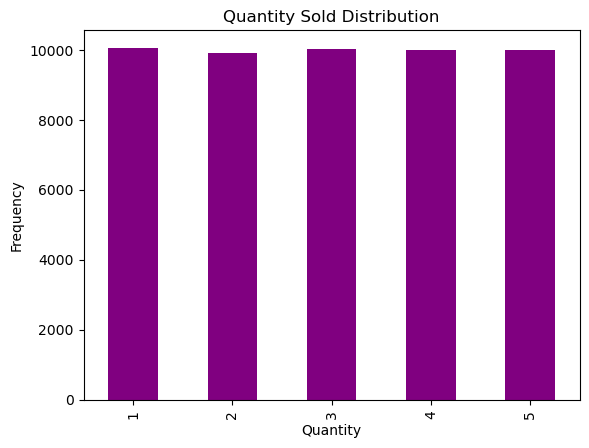

In [26]:
df['quantity_sold'].value_counts().sort_index().plot(kind='bar', color= 'Purple')
plt.title('Quantity Sold Distribution')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

In [ ]:
## Relationship Analysis
#This section explores the relationships between variables such as revenue, quantity sold, and profit.It helps identify patterns between variables.

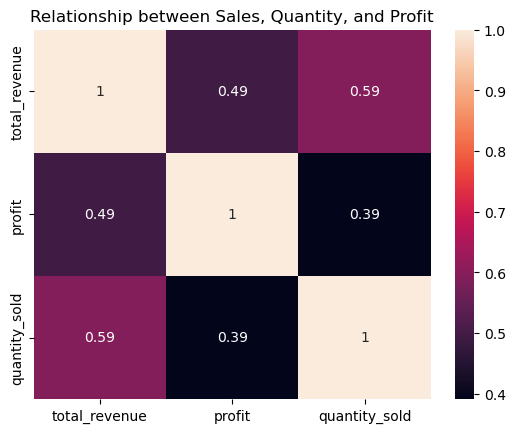

In [54]:
## What is the relationship between Sales, Quantity, and Profit? 
corr = df[['total_revenue','profit','quantity_sold']].corr()

sns.heatmap(corr, annot=True)
plt.title('Relationship between Sales, Quantity, and Profit')
plt.show()

In [ ]:
## Insight
#There is a strong positive relationship between quantity sold and revenue, as well as between revenue and profit.